# Post-Forecast EDA

Compare AutoETS vs Bayesian Hierarchical model across State×Ownership×Role hierarchy.

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../model/output')

# Load forecasts
ets = pd.read_csv(OUTPUT_DIR / 'forecast_rates.csv', parse_dates=['ds'])
bayes = pd.read_csv(OUTPUT_DIR / 'bayesian_forecast_rates.csv', parse_dates=['ds'])

# Load historical
panel = pd.read_csv(DATA_DIR / 'panel.csv', parse_dates=['month_end'])
emp = panel[panel['worker_type'] == 'Employee'].copy()
hist = emp.groupby(['state', 'ownership', 'role', 'month_end']).agg(
    active=('active_count', 'sum'), seps=('separation_count', 'sum')
).reset_index()
hist['rate'] = hist['seps'] / hist['active']

TRAIN_END = '2025-03-01'
VAL_START = '2025-04-01'
VAL_END = '2025-06-01'

# ID format (consistent across both models): State/Ownership/Role
# Roll-ups: National/total/total, National/total/CNA, National/For-Profit/total, TX/total/total, etc.
NATIONAL = 'National/total/total'
ROLES = {'CNA': 'National/total/CNA', 'LPN': 'National/total/LPN', 'RN': 'National/total/RN'}
OWNERSHIP = {'For-Profit': 'National/For-Profit/total', 'Non-Profit': 'National/Non-Profit/total', 'Government': 'National/Government/total'}

print(f'ETS: {ets["unique_id"].nunique()} series')
print(f'Bayes: {bayes["unique_id"].nunique()} series')

ETS: 791 series
Bayes: 791 series


## 1. National Forecast: All Models vs History

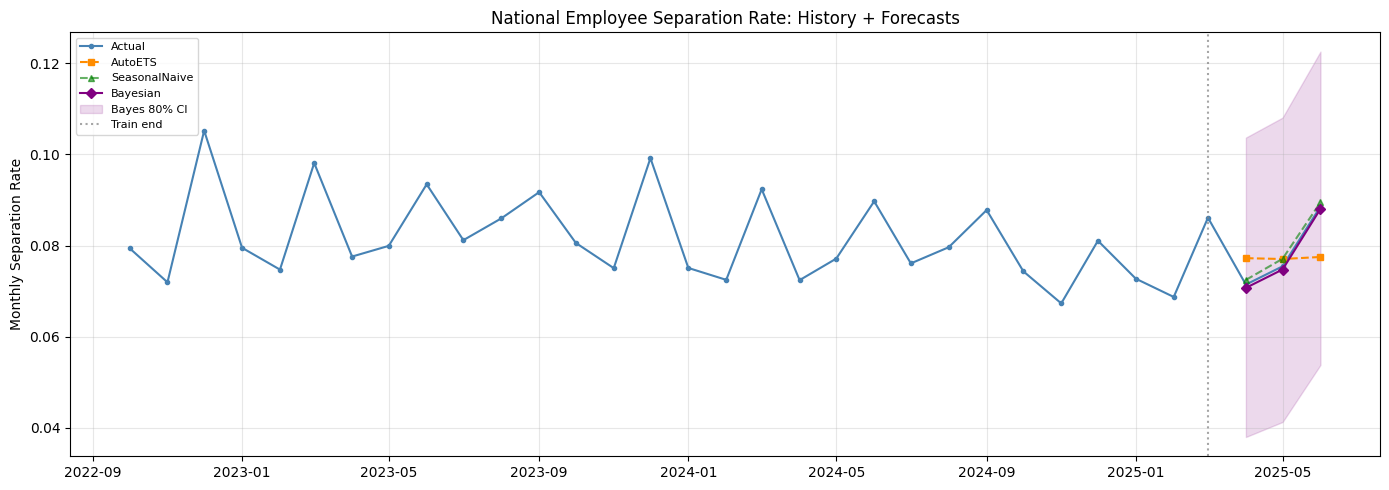

In [132]:
# National historical
nat_hist = hist[hist['month_end'] <= VAL_END].groupby('month_end').apply(
    lambda g: g['seps'].sum() / g['active'].sum(), include_groups=False
).reset_index(name='rate')

# ETS national forecast (validation period only)
nat_ets = ets[(ets['unique_id'] == NATIONAL) & (ets['ds'] <= VAL_END)][['ds', 'AutoETS', 'SeasonalNaive']]

# Bayes national forecast
nat_bayes = bayes[(bayes['unique_id'] == NATIONAL) & (bayes['ds'] <= VAL_END)][['ds', 'BayesHier', 'BayesHier-lo-80', 'BayesHier-hi-80']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nat_hist['month_end'], nat_hist['rate'], 'o-', markersize=3, color='steelblue', label='Actual')
if not nat_ets.empty:
    ax.plot(nat_ets['ds'], nat_ets['AutoETS'], 's--', markersize=4, color='darkorange', label='AutoETS')
    ax.plot(nat_ets['ds'], nat_ets['SeasonalNaive'], '^--', markersize=4, color='green', alpha=0.6, label='SeasonalNaive')
if not nat_bayes.empty:
    ax.plot(nat_bayes['ds'], nat_bayes['BayesHier'], 'D-', markersize=5, color='purple', label='Bayesian')
    ax.fill_between(nat_bayes['ds'], nat_bayes['BayesHier-lo-80'], nat_bayes['BayesHier-hi-80'],
                    alpha=0.15, color='purple', label='Bayes 80% CI')
ax.axvline(pd.Timestamp(TRAIN_END), color='gray', linestyle=':', alpha=0.7, label='Train end')
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('National Employee Separation Rate: History + Forecasts')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Forecast by Role

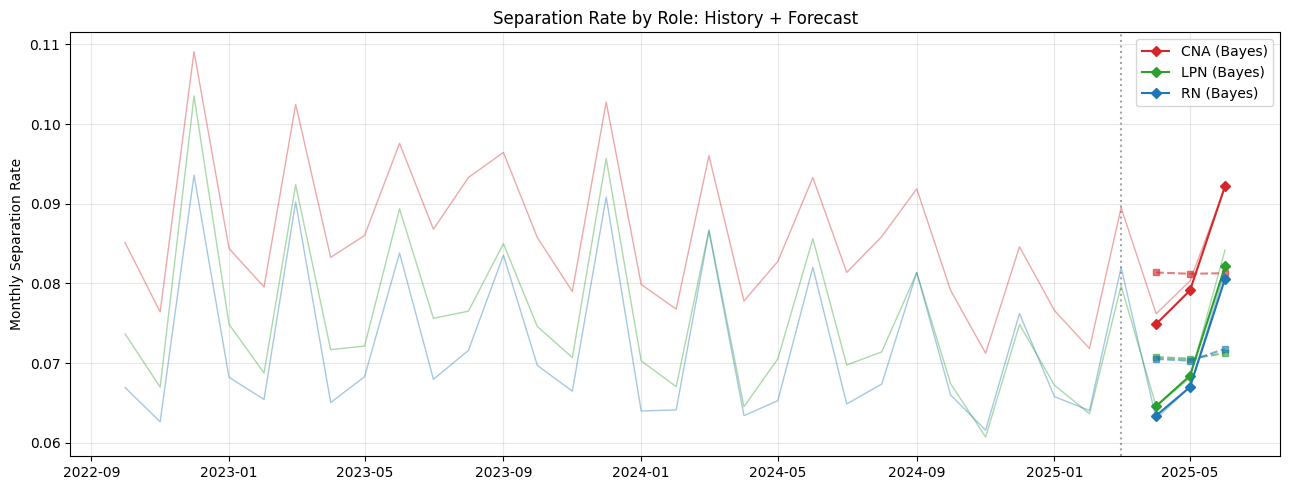

In [133]:
roles = ['CNA', 'LPN', 'RN']
colors = {'CNA': 'tab:red', 'LPN': 'tab:green', 'RN': 'tab:blue'}

fig, ax = plt.subplots(figsize=(13, 5))

for role in roles:
    # Historical (aggregate across states and ownership)
    rh = hist[hist['role'] == role].groupby('month_end').apply(
        lambda g: g['seps'].sum() / g['active'].sum(), include_groups=False
    ).reset_index(name='rate')
    rh = rh[rh['month_end'] <= VAL_END]
    ax.plot(rh['month_end'], rh['rate'], '-', color=colors[role], alpha=0.4, linewidth=1)

    # ETS forecast
    rf_ets = ets[(ets['unique_id'] == ROLES[role]) & (ets['ds'] <= VAL_END)]
    if not rf_ets.empty:
        ax.plot(rf_ets['ds'], rf_ets['AutoETS'], 's--', color=colors[role], markersize=4, alpha=0.6)

    # Bayes forecast
    rf_b = bayes[(bayes['unique_id'] == ROLES[role]) & (bayes['ds'] <= VAL_END)]
    if not rf_b.empty:
        ax.plot(rf_b['ds'], rf_b['BayesHier'], 'D-', color=colors[role], markersize=5, label=f'{role} (Bayes)')
    else:
        ax.plot([], [], 'D-', color=colors[role], markersize=5, label=f'{role} (no Bayes)')

ax.axvline(pd.Timestamp(TRAIN_END), color='gray', linestyle=':', alpha=0.7)
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('Separation Rate by Role: History + Forecast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forecast by Ownership Type

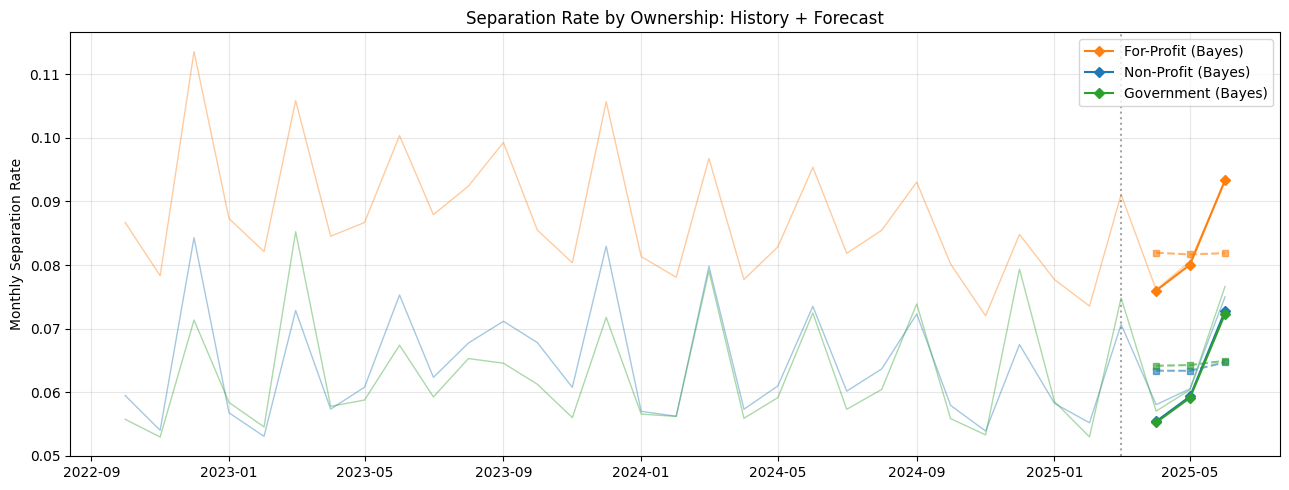

In [134]:
own_types = ['For-Profit', 'Non-Profit', 'Government']
own_colors = {'For-Profit': 'tab:orange', 'Non-Profit': 'tab:blue', 'Government': 'tab:green'}

fig, ax = plt.subplots(figsize=(13, 5))

for own in own_types:
    # Historical
    oh = hist[hist['ownership'] == own].groupby('month_end').apply(
        lambda g: g['seps'].sum() / g['active'].sum(), include_groups=False
    ).reset_index(name='rate')
    oh = oh[oh['month_end'] <= VAL_END]
    ax.plot(oh['month_end'], oh['rate'], '-', color=own_colors[own], alpha=0.4, linewidth=1)

    # ETS forecast
    rf_ets = ets[(ets['unique_id'] == OWNERSHIP[own]) & (ets['ds'] <= VAL_END)]
    if not rf_ets.empty:
        ax.plot(rf_ets['ds'], rf_ets['AutoETS'], 's--', color=own_colors[own], markersize=4, alpha=0.6)

    # Bayes forecast
    rf_b = bayes[(bayes['unique_id'] == OWNERSHIP[own]) & (bayes['ds'] <= VAL_END)]
    if not rf_b.empty:
        ax.plot(rf_b['ds'], rf_b['BayesHier'], 'D-', color=own_colors[own], markersize=5, label=f'{own} (Bayes)')
    else:
        ax.plot([], [], 'D-', color=own_colors[own], markersize=5, label=f'{own} (ETS only)')

ax.axvline(pd.Timestamp(TRAIN_END), color='gray', linestyle=':', alpha=0.7)
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('Separation Rate by Ownership: History + Forecast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. State-Level Forecast Distribution

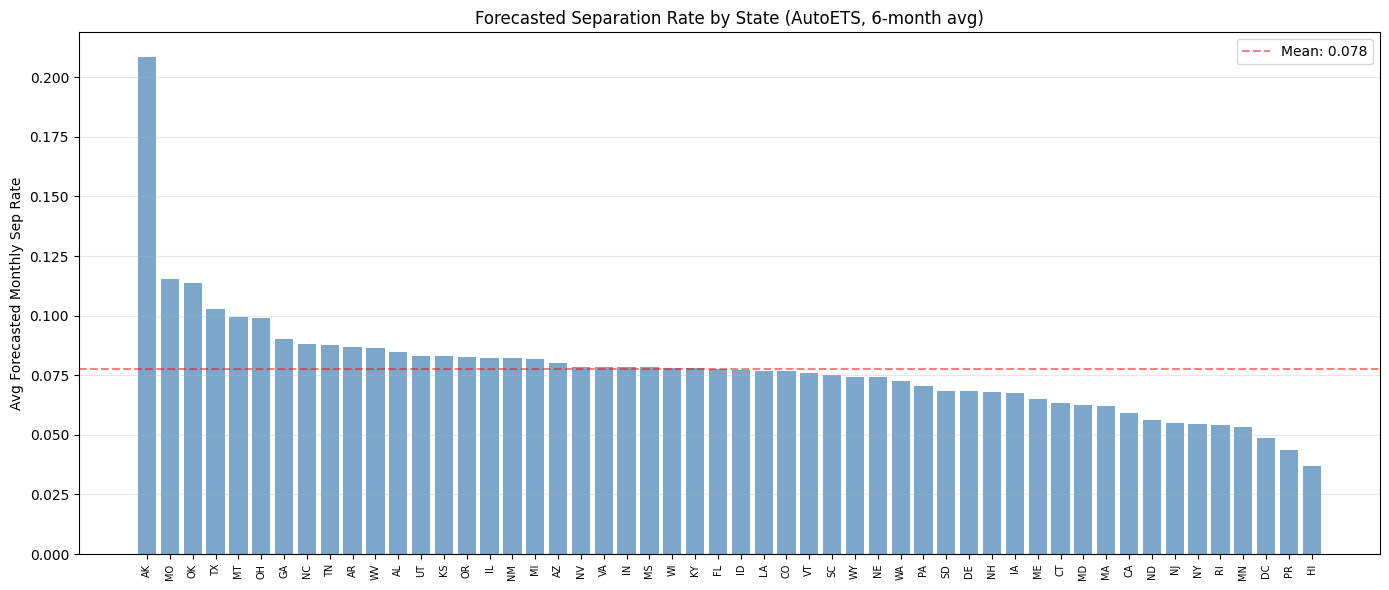

Top 10 (highest):
state
AK    0.208434
MO    0.115217
OK    0.113852
TX    0.102645
MT    0.099273
OH    0.099127
GA    0.090377
NC    0.087986
TN    0.087860
AR    0.086929

Bottom 5 (lowest):
state
RI    0.054096
MN    0.053458
DC    0.048586
PR    0.043752
HI    0.036916


In [135]:
# State-level from ETS (format: 'XX/total/total')
state_fcst = ets[ets['unique_id'].str.match(r'^[A-Z]{2}/total/total$')].copy()
state_fcst['state'] = state_fcst['unique_id'].str[:2]
state_avg = state_fcst.groupby('state')['AutoETS'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(state_avg)), state_avg.values, color='steelblue', alpha=0.7)
ax.set_xticks(range(len(state_avg)))
ax.set_xticklabels(state_avg.index, rotation=90, fontsize=7)
ax.axhline(state_avg.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {state_avg.mean():.3f}')
ax.set_ylabel('Avg Forecasted Monthly Sep Rate')
ax.set_title('Forecasted Separation Rate by State (AutoETS, 6-month avg)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Top 10 (highest):')
print(state_avg.head(10).to_string())
print(f'\nBottom 5 (lowest):')
print(state_avg.tail(5).to_string())

## 5. Validation: Forecast vs Actual (Apr–Jun 2025)

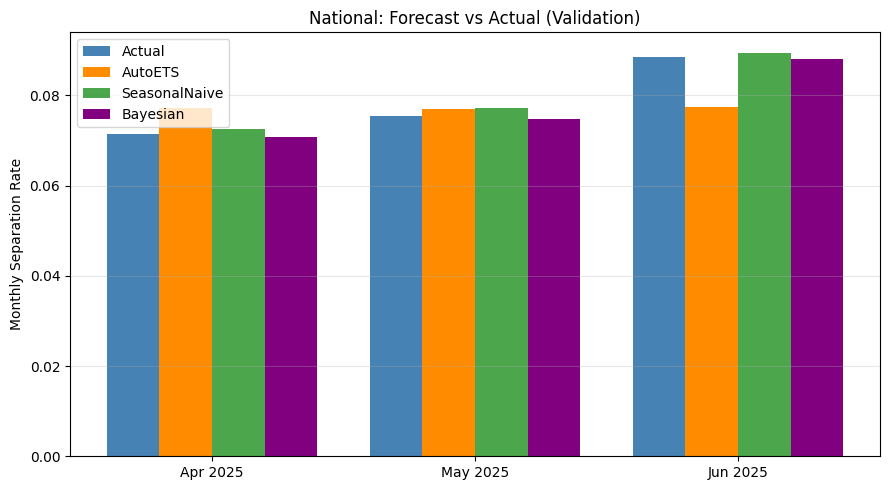

National validation MAE (pp):
  AutoETS              0.62 pp
  SeasonalNaive        0.12 pp
  BayesHier            0.06 pp


In [136]:
# National actuals for validation period
nat_val = hist[(hist['month_end'] >= VAL_START) & (hist['month_end'] <= VAL_END)]
nat_val_agg = nat_val.groupby('month_end').apply(
    lambda g: g['seps'].sum() / g['active'].sum(), include_groups=False
).reset_index(name='actual')

nat_compare = nat_val_agg.rename(columns={'month_end': 'ds'})
if not nat_ets.empty:
    nat_compare = nat_compare.merge(nat_ets, on='ds', how='left')
if not nat_bayes.empty:
    nat_compare = nat_compare.merge(nat_bayes[['ds', 'BayesHier']], on='ds', how='left')

if not nat_compare.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(nat_compare))
    w = 0.2
    ax.bar(x - 1.5*w, nat_compare['actual'], width=w, label='Actual', color='steelblue')
    if 'AutoETS' in nat_compare.columns:
        ax.bar(x - 0.5*w, nat_compare['AutoETS'], width=w, label='AutoETS', color='darkorange')
    if 'SeasonalNaive' in nat_compare.columns:
        ax.bar(x + 0.5*w, nat_compare['SeasonalNaive'], width=w, label='SeasonalNaive', color='green', alpha=0.7)
    if 'BayesHier' in nat_compare.columns:
        ax.bar(x + 1.5*w, nat_compare['BayesHier'], width=w, label='Bayesian', color='purple')
    ax.set_xticks(x)
    ax.set_xticklabels(nat_compare['ds'].dt.strftime('%b %Y'))
    ax.set_ylabel('Monthly Separation Rate')
    ax.set_title('National: Forecast vs Actual (Validation)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print('National validation MAE (pp):')
    for col in ['AutoETS', 'SeasonalNaive', 'BayesHier']:
        if col in nat_compare.columns and nat_compare[col].notna().any():
            mae = (nat_compare[col] - nat_compare['actual']).abs().mean()
            print(f'  {col:<20s} {mae*100:.2f} pp')

## 6. Model Comparison: Workforce-Weighted wMAPE by Level

In [137]:
# Build validation actuals at bottom level (State×Ownership×Role)
val_period = hist[(hist['month_end'] >= VAL_START) & (hist['month_end'] <= VAL_END)]
val_period = val_period.copy()
val_period['unique_id'] = val_period['state'] + '/' + val_period['ownership'] + '/' + val_period['role']
val_actuals = val_period[['unique_id', 'month_end', 'rate', 'active']].rename(
    columns={'month_end': 'ds', 'rate': 'actual'}
)

# Merge ETS and Bayes forecasts with actuals
eval_ets = ets.merge(val_actuals, on=['unique_id', 'ds'], how='inner')
eval_bayes = bayes.merge(val_actuals, on=['unique_id', 'ds'], how='inner')

print(f'{"Model":<40s} {"MAE":>8s} {"wMAPE":>10s} {"n":>5s}')
print('-' * 65)

for label, df, col in [
    ('AutoETS', eval_ets, 'AutoETS'),
    ('SeasonalNaive', eval_ets, 'SeasonalNaive'),
    ('Bayesian Hierarchical', eval_bayes, 'BayesHier'),
]:
    if col in df.columns and not df.empty:
        err = df[col] - df['actual']
        mae = err.abs().mean()
        wmape = (err.abs() * df['active']).sum() / (df['actual'].abs() * df['active']).sum()
        print(f'{label:<40s} {mae:>8.5f} {wmape:>9.1%} {len(df):>5d}')

Model                                         MAE      wMAPE     n
-----------------------------------------------------------------
AutoETS                                   0.01930     12.5%  1278
SeasonalNaive                             0.02076     13.7%  1278
Bayesian Hierarchical                     0.01546      9.3%  1278


## 7. Bayesian Model In-Sample Fit

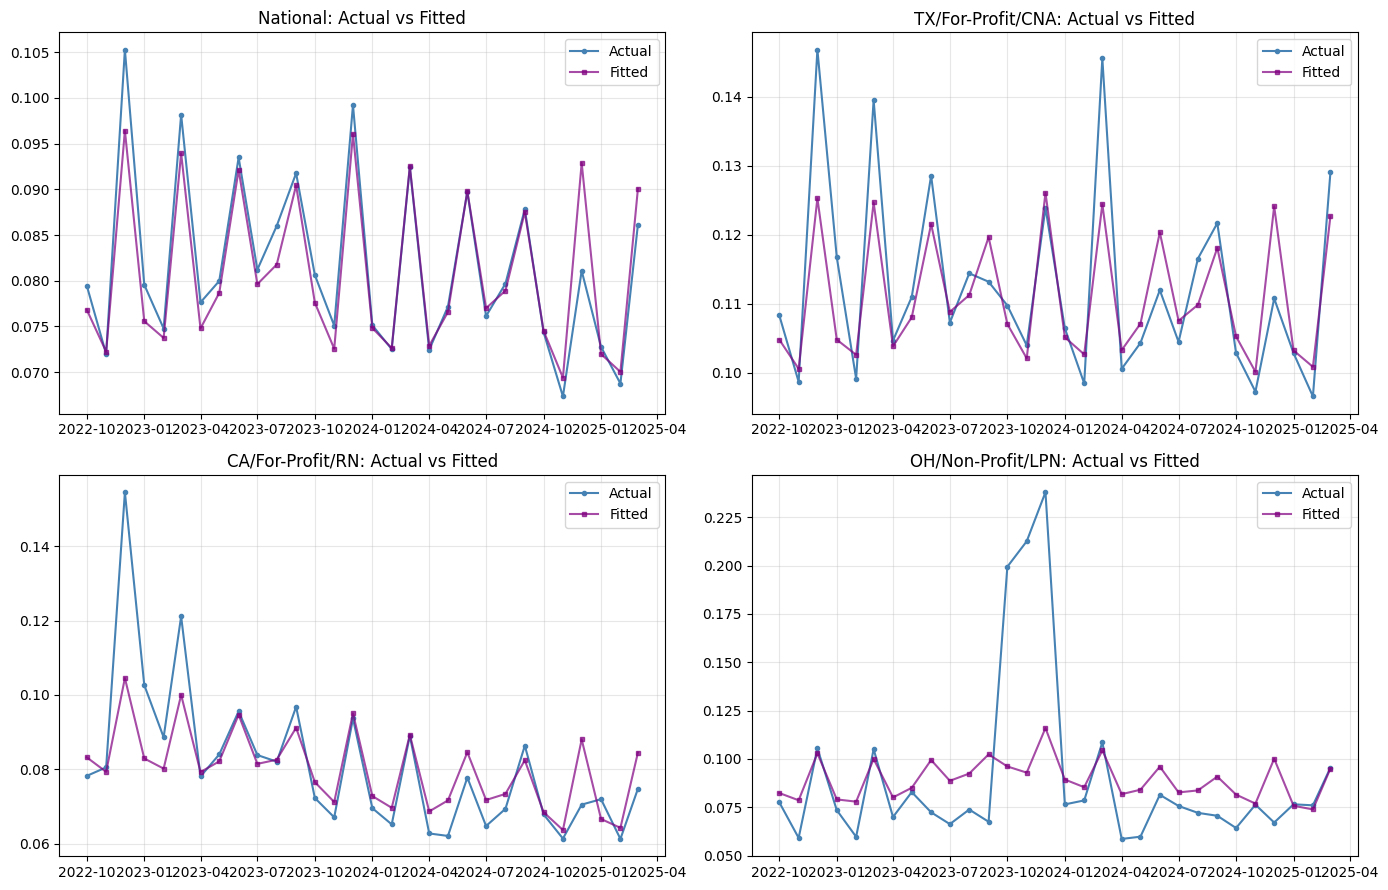

In-sample MAE: 0.01337
In-sample R²: 0.553


In [138]:
fitted_path = OUTPUT_DIR / 'bayesian_fitted_values.csv'
if fitted_path.exists():
    fitted = pd.read_csv(fitted_path, parse_dates=['ds'])

    # National fitted (weighted roll-up)
    hist_with_id = hist.copy()
    hist_with_id['unique_id'] = hist_with_id['state'] + '/' + hist_with_id['ownership'] + '/' + hist_with_id['role']
    fitted_w = fitted.merge(
        hist_with_id[['unique_id', 'month_end', 'active']].rename(columns={'month_end': 'ds'}),
        on=['unique_id', 'ds'], how='left'
    )
    nat_fitted = fitted_w.groupby('ds').apply(
        lambda g: pd.Series({
            'fitted': (g['fitted'] * g['active']).sum() / g['active'].sum() if g['active'].sum() > 0 else 0,
            'actual': (g['actual'] * g['active']).sum() / g['active'].sum() if g['active'].sum() > 0 else 0,
        }), include_groups=False
    ).reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # National
    ax = axes[0, 0]
    ax.plot(nat_fitted['ds'], nat_fitted['actual'], 'o-', markersize=3, color='steelblue', label='Actual')
    ax.plot(nat_fitted['ds'], nat_fitted['fitted'], 's-', markersize=3, color='purple', alpha=0.7, label='Fitted')
    ax.set_title('National: Actual vs Fitted')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Sample series
    sample_series = ['TX/For-Profit/CNA', 'CA/For-Profit/RN', 'OH/Non-Profit/LPN']
    for i, series in enumerate(sample_series):
        ax = axes[(i+1)//2, (i+1)%2]
        s_data = fitted[fitted['unique_id'] == series].sort_values('ds')
        if not s_data.empty:
            ax.plot(s_data['ds'], s_data['actual'], 'o-', markersize=3, color='steelblue', label='Actual')
            ax.plot(s_data['ds'], s_data['fitted'], 's-', markersize=3, color='purple', alpha=0.7, label='Fitted')
            ax.set_title(f'{series}: Actual vs Fitted')
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # In-sample metrics
    insample_err = (fitted['fitted'] - fitted['actual']).abs()
    print(f'In-sample MAE: {insample_err.mean():.5f}')
    print(f'In-sample R²: {1 - ((fitted["fitted"] - fitted["actual"])**2).sum() / ((fitted["actual"] - fitted["actual"].mean())**2).sum():.3f}')
else:
    print('No fitted values file. Run bayesian_hierarchical.py first.')

## 8. Quarter-End Pattern Check

In [139]:
# Historical pattern
nat_h = nat_hist.copy()
nat_h['is_qtr_end'] = nat_h['month_end'].dt.month.isin([3, 6, 9, 12])
qtr_h = nat_h[nat_h['is_qtr_end']]['rate'].mean()
mid_h = nat_h[~nat_h['is_qtr_end']]['rate'].mean()
print(f'Historical quarter-end pattern:')
print(f'  Quarter-end avg: {qtr_h:.4f} ({qtr_h*100:.1f}%)')
print(f'  Mid-quarter avg: {mid_h:.4f} ({mid_h*100:.1f}%)')
print(f'  Uplift: {(qtr_h-mid_h)*100:.2f} pp ({(qtr_h/mid_h-1)*100:.1f}% relative)')

# ETS forecast pattern
if not nat_ets.empty:
    ne = nat_ets.copy()
    ne['is_qtr_end'] = ne['ds'].dt.month.isin([3, 6, 9, 12])
    if ne['is_qtr_end'].any() and (~ne['is_qtr_end']).any():
        qtr_e = ne[ne['is_qtr_end']]['AutoETS'].mean()
        mid_e = ne[~ne['is_qtr_end']]['AutoETS'].mean()
        print(f'\nAutoETS forecast pattern:')
        print(f'  Quarter-end avg: {qtr_e:.4f}, Mid-quarter avg: {mid_e:.4f}')
        print(f'  Uplift: {(qtr_e-mid_e)*100:.2f} pp')

# Bayes forecast pattern
if not nat_bayes.empty:
    nb = nat_bayes.copy()
    nb['is_qtr_end'] = nb['ds'].dt.month.isin([3, 6, 9, 12])
    if nb['is_qtr_end'].any() and (~nb['is_qtr_end']).any():
        qtr_b = nb[nb['is_qtr_end']]['BayesHier'].mean()
        mid_b = nb[~nb['is_qtr_end']]['BayesHier'].mean()
        print(f'\nBayesian forecast pattern:')
        print(f'  Quarter-end avg: {qtr_b:.4f}, Mid-quarter avg: {mid_b:.4f}')
        print(f'  Uplift: {(qtr_b-mid_b)*100:.2f} pp')

Historical quarter-end pattern:
  Quarter-end avg: 0.0921 (9.2%)
  Mid-quarter avg: 0.0759 (7.6%)
  Uplift: 1.63 pp (21.4% relative)

AutoETS forecast pattern:
  Quarter-end avg: 0.0775, Mid-quarter avg: 0.0771
  Uplift: 0.04 pp

Bayesian forecast pattern:
  Quarter-end avg: 0.0881, Mid-quarter avg: 0.0727
  Uplift: 1.53 pp
